In [43]:
# using Revise
import Deborah; flush(stdout); flush(stderr)

In [44]:
const PROJECT_ROOT = joinpath(homedir(), "work", "Deborah.jl")
function localpath(relpath::AbstractString)
    return joinpath(PROJECT_ROOT, relpath)
end
import TOML

ns=12
nt=4
b="1.60"
kappa="13580"

ensemble="L$(ns)T$(nt)b$(b)k$(kappa)"

work = "nf4_clover_wilson_finiteT"

raw_path = localpath(joinpath(work, ensemble))

jobid = nothing

In [45]:
import Statistics

observable="plaq.dat"
# observable="rect.dat"
# observable="trdinv4.dat"

X_df = Deborah.Sarah.DataLoader.load_data_file(raw_path, observable, jobid)

N_cnf = size(X_df, 1)
N_src = 1
read_column_X = 1

bin_size = 1

X_info = Deborah.Sarah.XYInfoGenerator.gen_X_info(X_df, N_cnf, N_src, read_column_X)

X_info_ORG = [Statistics.mean(X_info[read_column_X, iconf, :]) for iconf in 1:N_cnf]

conf_idx_vec = 1:N_cnf
conf_idx = collect(conf_idx_vec)

Deborah.Rebekah.PyPlotLaTeX.set_pyplot_latex_style()

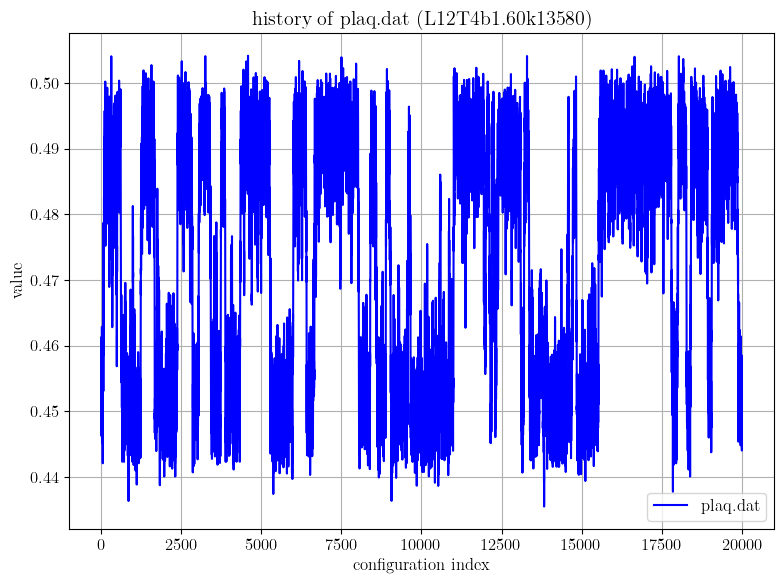

In [46]:
Deborah.Rahab.ObservableHistory.observable_history(ensemble, conf_idx, X_info_ORG, observable)

[2026-02-24 16:11:39.707] Divisors of 1000: [1, 2, 4, 5, 8, 10, 20, 25, 40, 50, 100, 125, 200, 250, 500, 1000]


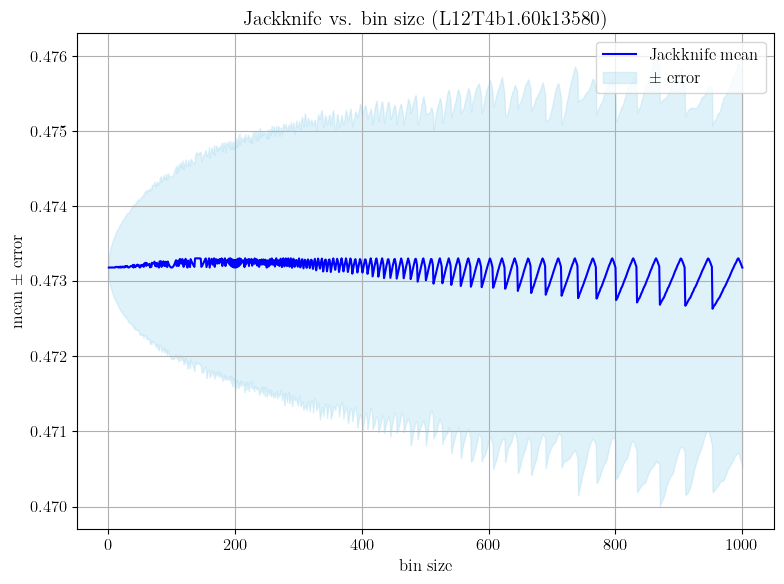

([0.4731809503772409, 0.47318095037724095, 0.47318305044597875, 0.47318095037724095, 0.47318095037724095, 0.47318305044597875, 0.47318177434433323, 0.4731809503772409, 0.4731830504459788, 0.47318095037724095  …  0.4732664761164738, 0.47328525888234785, 0.4733014691262657, 0.4733029708606019, 0.4732804580926574, 0.473266511788915, 0.47324653551078477, 0.4732243613049806, 0.47320203892371415, 0.4731809503772407], [0.0001344797000309474, 0.0001892518893286455, 0.0002311215290459593, 0.00026625333347788277, 0.00029702098018341994, 0.00032475157782717795, 0.00035018476719023513, 0.00037366064945563093, 0.0003958612190113307, 0.00041652268204293727  …  0.0025652317915127038, 0.0025750739948427522, 0.002588602820092348, 0.002595621982224775, 0.0026003518029144874, 0.002609918559329765, 0.00261654307656752, 0.0026247799190897373, 0.0026384456756856542, 0.0026468751906088914])

In [47]:
# ---- compute divisors of tot_bin ----
tot_bin = 1000

# Sweep block size
max_bin = min(tot_bin, N_cnf)
bin_sizes = collect(1:max_bin)

means, errs = Deborah.Rahab.BlockBinScan.jackknife_bin_scan(
    ensemble,
    X_info_ORG, 
    bin_sizes,
    tot_bin
)

In [48]:
win = 40  # window of block size; e.g., 10 means [1..10], [11..20], ... 

40

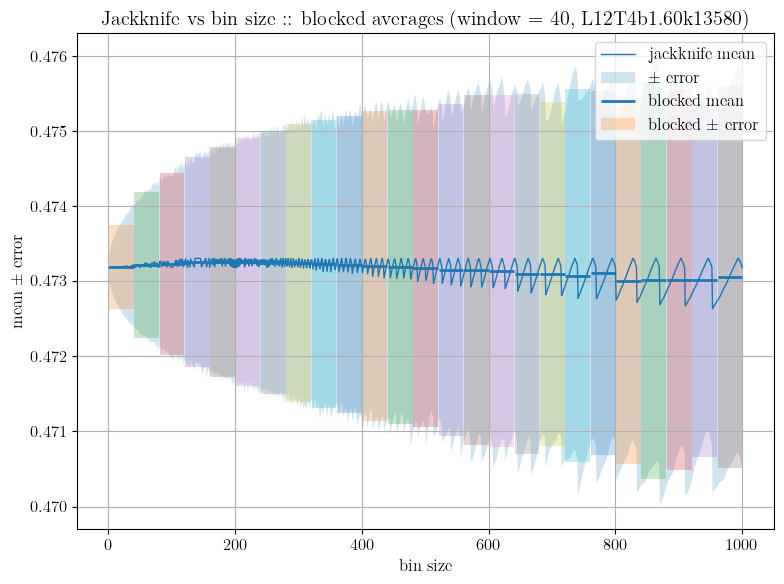

In [49]:
Deborah.Rahab.BlockBinScan.jackknife_bin_scan_blocked_average(
    ensemble,
    bin_sizes,
    means,
    errs,
    win;
    include_tail=false
)

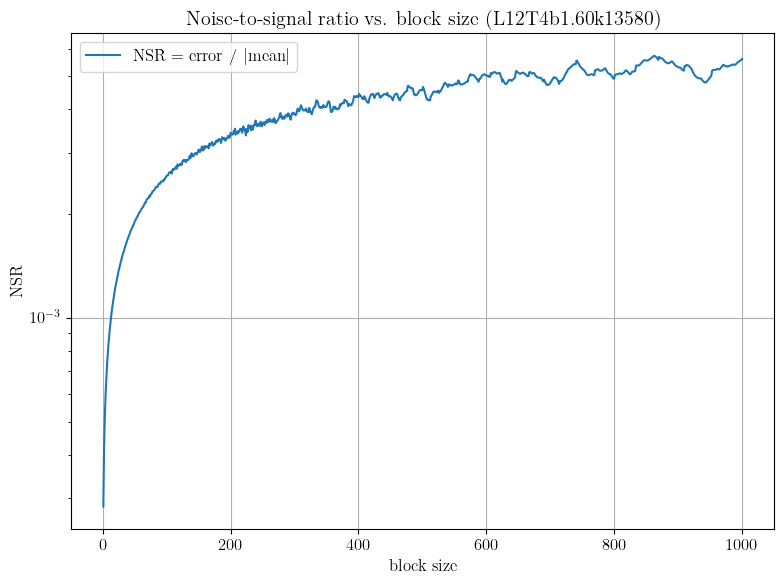

In [50]:
Deborah.Rahab.BlockBinScan.nsr_block_scan(
    ensemble,
    bin_sizes,
    means,
    errs;
    logscale=true
)


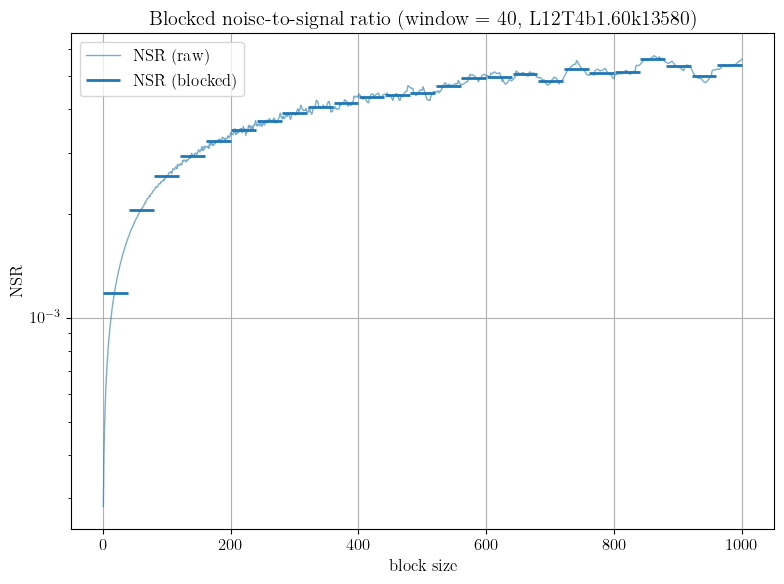

In [51]:
Deborah.Rahab.BlockBinScan.nsr_block_scan_blocked_average(
    ensemble,
    bin_sizes,
    means,
    errs,
    win;
    include_tail=false,
    logscale=true
)

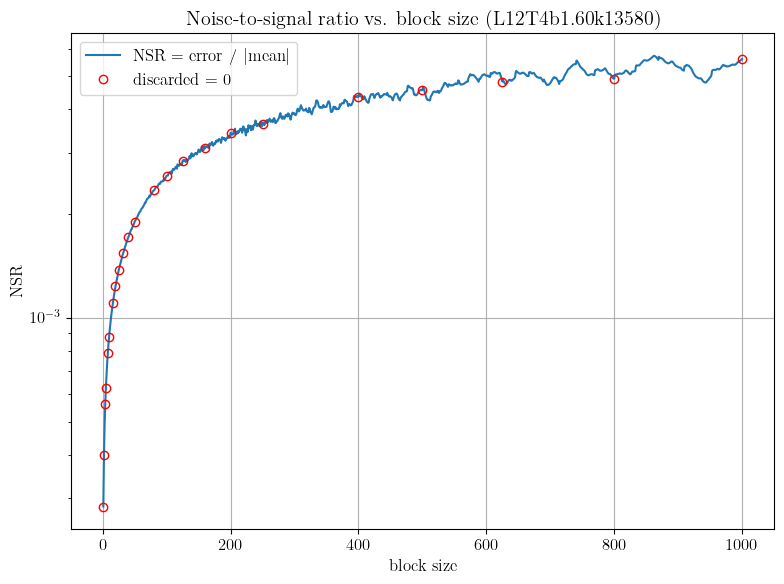

([1, 2, 4, 5, 8, 10, 16, 20, 25, 32  …  100, 125, 160, 200, 250, 400, 500, 625, 800, 1000], [0.0002842035376186091, 0.0003999566955892148, 0.0005626881920449539, 0.000627711195783815, 0.0007896781329800619, 0.0008802608847859721, 0.001104281678113402, 0.0012305570752148616, 0.001369011443349323, 0.0015360488991257458  …  0.0025712665138360484, 0.0028433746293542706, 0.0030873354682628452, 0.0034252330046808843, 0.003630697634165157, 0.0043443951067831735, 0.004552549536156089, 0.004816162080501126, 0.0049056344193894605, 0.005593790680919606], [0, 0, 2, 0, 0, 2, 1, 0, 2, 0  …  180, 160, 140, 120, 100, 80, 60, 40, 20, 0])

In [52]:
Deborah.Rahab.BlockBinScan.nsr_block_scan_with_discarded_zero(
    ensemble,
    X_info_ORG,
    tot_bin,
    means,
    errs;
    logscale=true
)

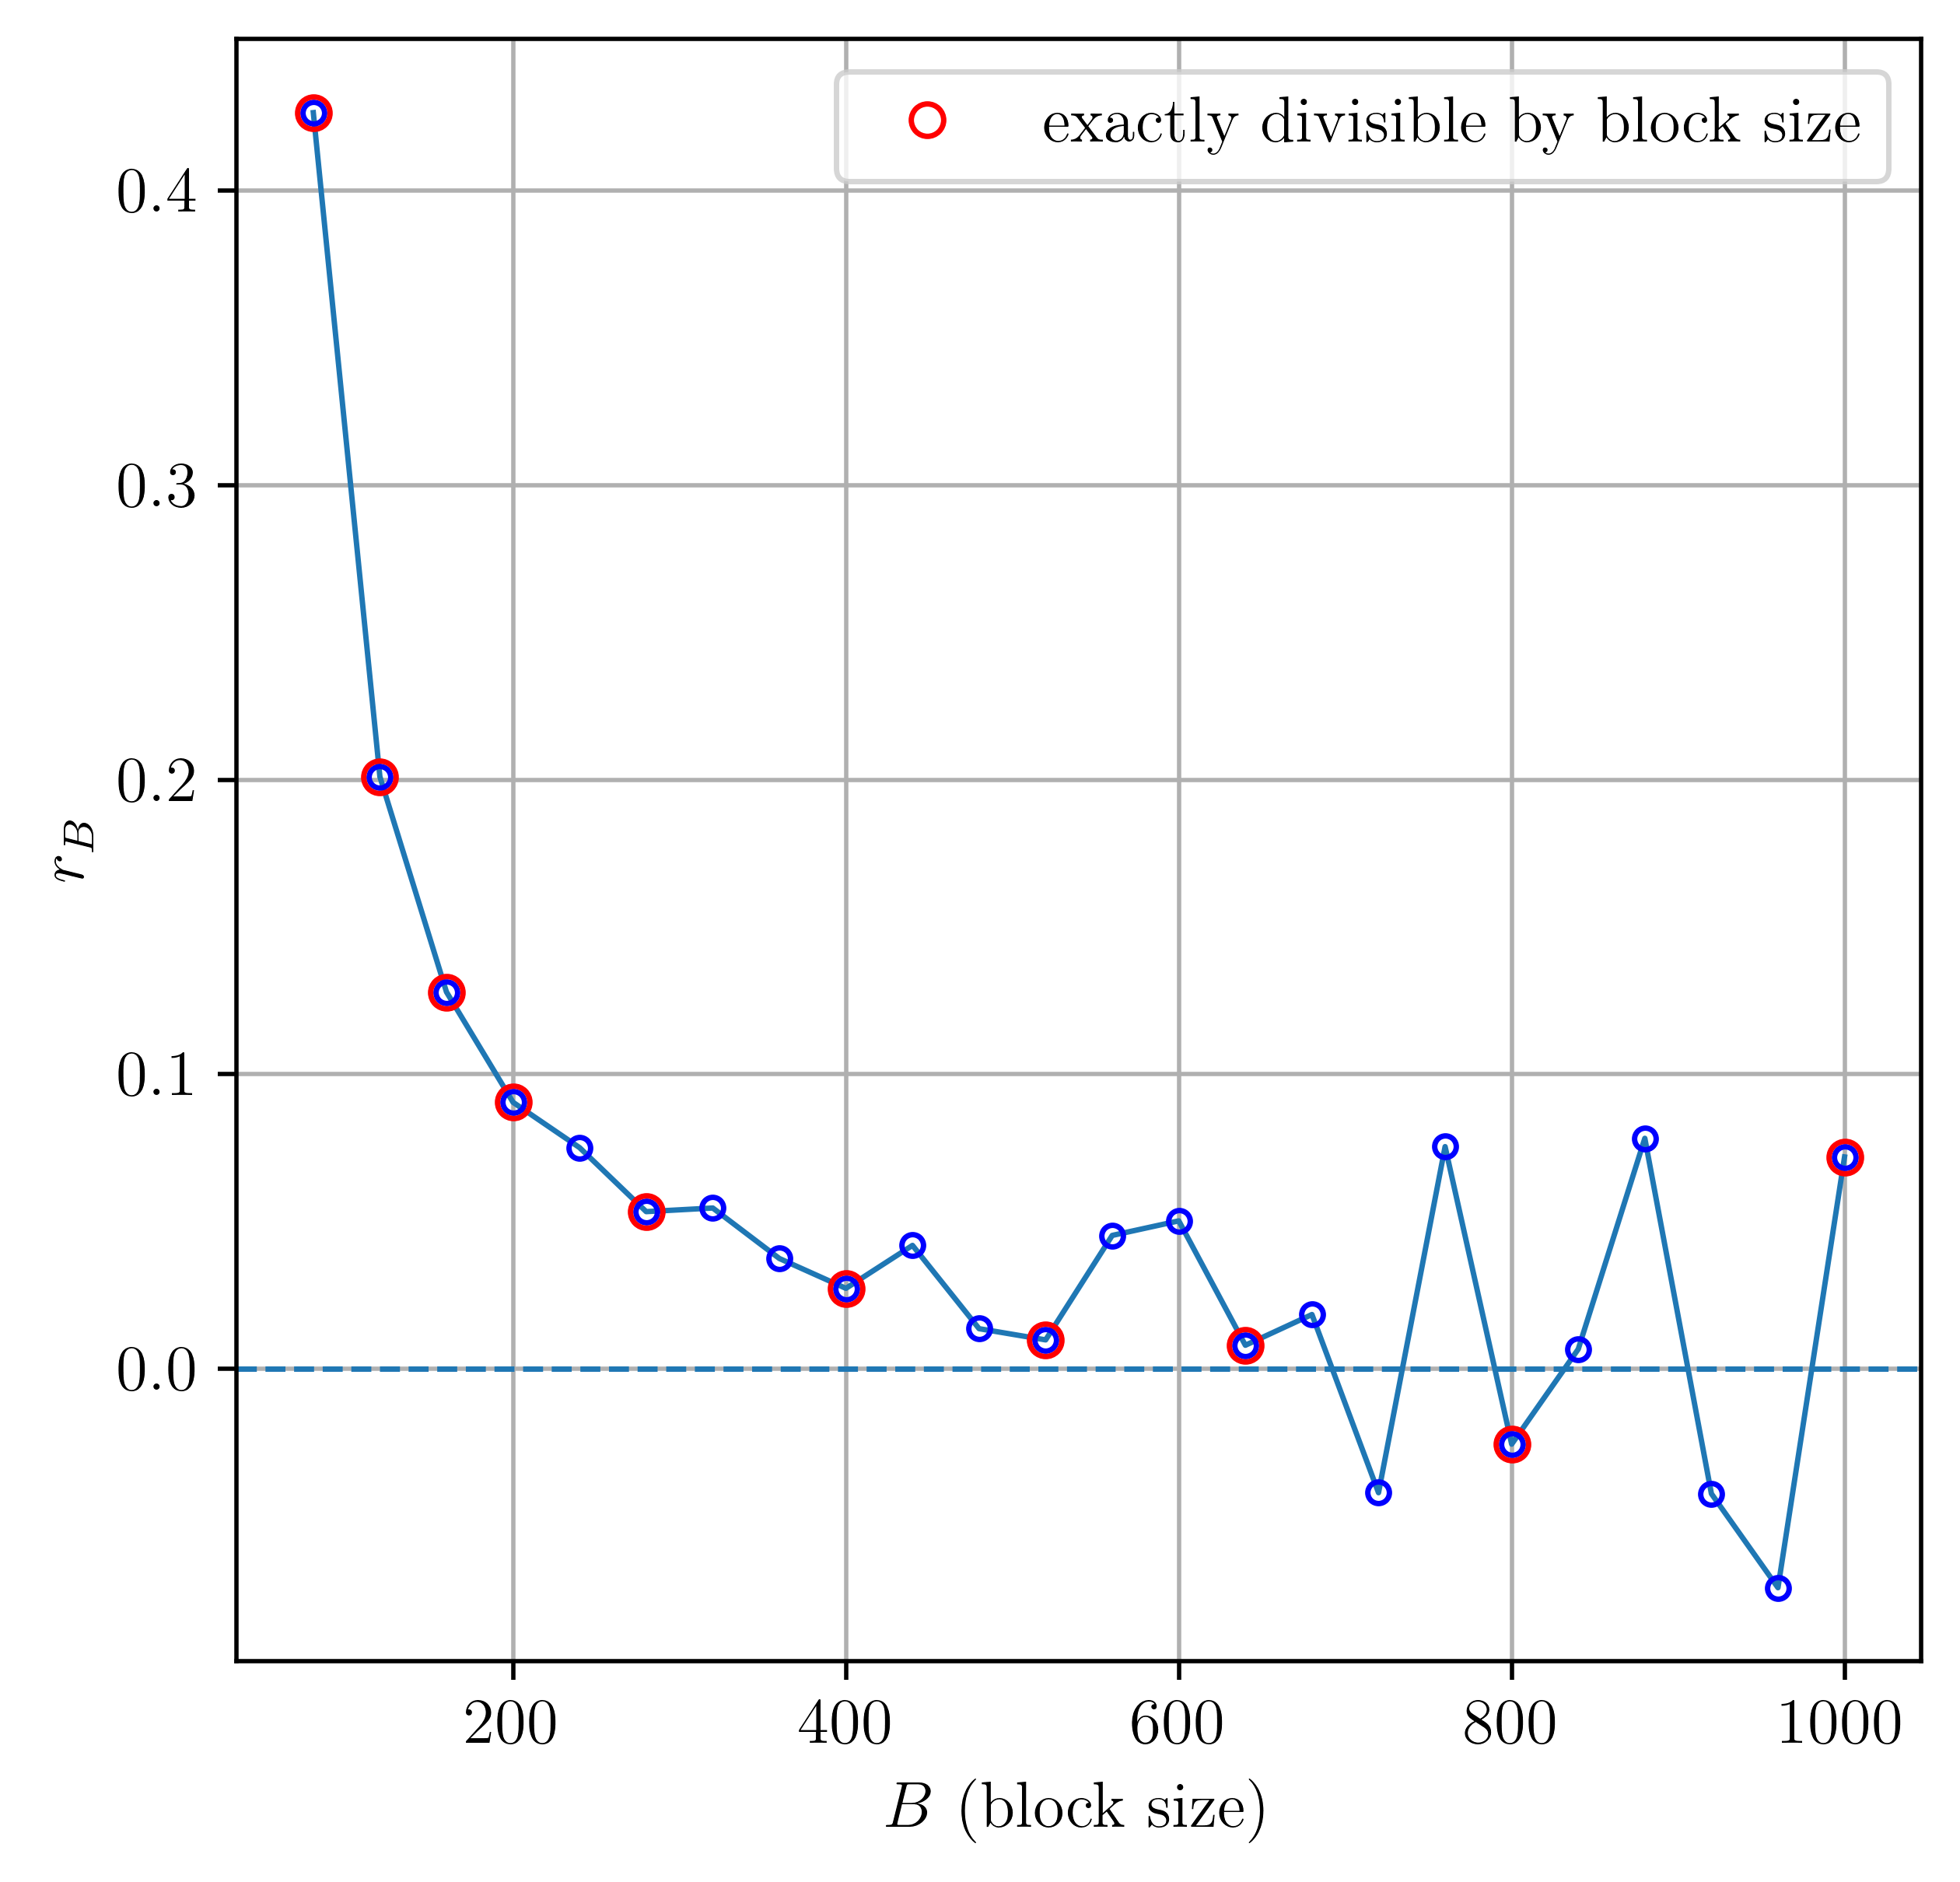

[2026-02-24 16:11:42.445] block sizes with discarded == 0: [1, 2, 4, 5, 8, 10, 16, 20, 25, 32, 40, 50, 80, 100, 125, 160, 200, 250, 400, 500, 625, 800, 1000]
[2026-02-24 16:11:42.446] window indices (k) that contain any discarded == 0: [2, 3, 4, 5, 7, 10, 13, 16, 20, 25]
[2026-02-24 16:11:42.446] x(right-edge) for those windows: [80, 120, 160, 200, 280, 400, 520, 640, 800, 1000]


([80, 120, 160, 200, 280, 400, 520, 640, 800, 1000], [0.42638287369033673, 0.20100335826876287, 0.1279431830561525, 0.09050303089480796, 0.05339343688585159, 0.027354906253446155, 0.00986875447588468, 0.008037798171982165, -0.02552967834762397, 0.07196725389967921], [0, 0, 2, 0, 0, 2, 1, 0, 2, 0  …  180, 160, 140, 120, 100, 80, 60, 40, 20, 0])

In [53]:
xs, ys, discarded = Deborah.Rahab.BlockBinScan.nsr_block_scan_blocked_relchange(
    ensemble,
    X_info_ORG,
    tot_bin,
    means,
    errs,
    win;
    logscale=false
)

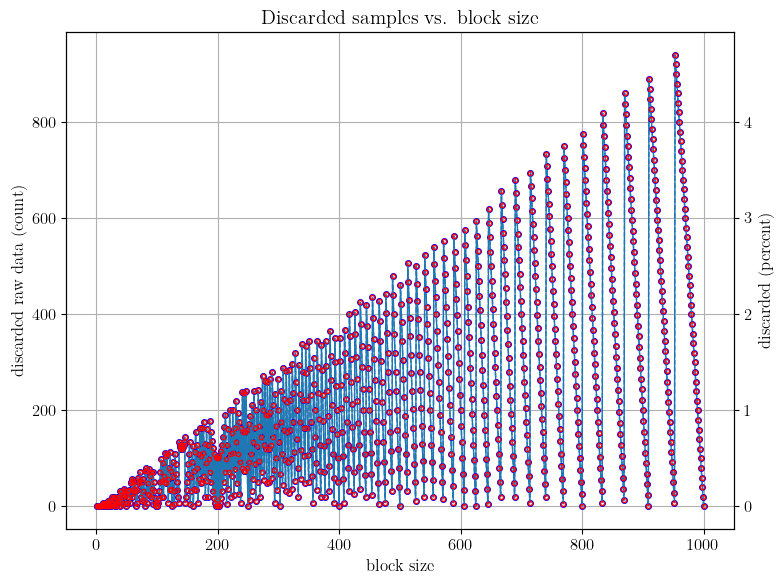

1000-element Vector{Int64}:
   0
   0
   2
   0
   0
   2
   1
   0
   2
   0
   ⋮
 160
 140
 120
 100
  80
  60
  40
  20
   0

In [54]:
Deborah.Rahab.BlockBinScan.plot_discarded_vs_blocks(
    X_info_ORG,
    tot_bin;
    style="both"
)